In [173]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pickle

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error



In [174]:
df=pd.read_csv(r'C:\Users\anura\OneDrive\Desktop\ml\ML-Projects\Travel Package Prediction\travel_dataset.csv')
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [175]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                4888 non-null   int64  
 1   ProdTaken                 4888 non-null   int64  
 2   Age                       4662 non-null   float64
 3   TypeofContact             4863 non-null   object 
 4   CityTier                  4888 non-null   int64  
 5   DurationOfPitch           4637 non-null   float64
 6   Occupation                4888 non-null   object 
 7   Gender                    4888 non-null   object 
 8   NumberOfPersonVisiting    4888 non-null   int64  
 9   NumberOfFollowups         4843 non-null   float64
 10  ProductPitched            4888 non-null   object 
 11  PreferredPropertyStar     4862 non-null   float64
 12  MaritalStatus             4888 non-null   object 
 13  NumberOfTrips             4748 non-null   float64
 14  Passport

In [176]:
df.isna().sum()

CustomerID                    0
ProdTaken                     0
Age                         226
TypeofContact                25
CityTier                      0
DurationOfPitch             251
Occupation                    0
Gender                        0
NumberOfPersonVisiting        0
NumberOfFollowups            45
ProductPitched                0
PreferredPropertyStar        26
MaritalStatus                 0
NumberOfTrips               140
Passport                      0
PitchSatisfactionScore        0
OwnCar                        0
NumberOfChildrenVisiting     66
Designation                   0
MonthlyIncome               233
dtype: int64

In [177]:
df[df['DurationOfPitch'].isna()]

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
46,200046,0,34.0,Company Invited,3,NaN,Small Business,Male,3,3.0,Deluxe,3.0,Single,1.0,0,5,1,1.0,Manager,19568.0
75,200075,0,31.0,Self Enquiry,1,NaN,Salaried,Female,3,3.0,Deluxe,3.0,Single,2.0,0,5,0,1.0,Manager,NaN
76,200076,0,35.0,Self Enquiry,3,NaN,Small Business,Male,2,4.0,Deluxe,5.0,Single,1.0,0,2,0,1.0,Manager,NaN
84,200084,0,34.0,Self Enquiry,1,NaN,Small Business,Male,3,3.0,Deluxe,4.0,Divorced,2.0,0,5,0,0.0,Manager,NaN
103,200103,0,34.0,Self Enquiry,1,NaN,Salaried,Female,2,3.0,Deluxe,3.0,Single,2.0,0,3,1,0.0,Manager,19809.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4215,204215,0,19.0,Self Enquiry,3,NaN,Small Business,Female,4,5.0,Basic,3.0,Single,3.0,0,1,0,3.0,Executive,19878.0
4427,204427,1,21.0,Self Enquiry,1,NaN,Small Business,Male,3,4.0,Basic,3.0,Single,3.0,1,5,1,2.0,Executive,19687.0
4641,204641,0,19.0,Company Invited,1,NaN,Salaried,Male,4,4.0,Basic,3.0,Single,3.0,0,1,0,2.0,Executive,19729.0
4678,204678,0,29.0,Self Enquiry,3,NaN,Small Business,Male,4,4.0,Basic,4.0,Married,3.0,0,5,0,3.0,Executive,19730.0


In [178]:
df["TypeofContact"] = df["TypeofContact"].replace({
    "Self Enquiry": "Self Inquiry"
})
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    df[col] = df[col].str.strip()

In [179]:
# Age
df['Age'].fillna(df['Age'].median(), inplace=True)

# Type of contact
df['TypeofContact'].fillna(df['TypeofContact'].mode()[0], inplace=True)

# Duration of pitch
df['DurationOfPitch'].fillna(df['DurationOfPitch'].median(), inplace=True)

# Number of followups
df['NumberOfFollowups'].fillna(0, inplace=True)

# Preferred property star
df['PreferredPropertyStar'].fillna(df['PreferredPropertyStar'].median(), inplace=True)

# Number of trips
df['NumberOfTrips'].fillna(df['NumberOfTrips'].median(), inplace=True)

# Number of children visiting
df['NumberOfChildrenVisiting'].fillna(0, inplace=True)

# Monthly income
df['MonthlyIncome'].fillna(df['MonthlyIncome'].median(), inplace=True)

C:\Users\anura\AppData\Local\Temp\ipykernel_18120\324356189.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
C:\Users\anura\AppData\Local\Temp\ipykernel_18120\324356189.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa

In [180]:
df.isna().sum()

CustomerID                  0
ProdTaken                   0
Age                         0
TypeofContact               0
CityTier                    0
DurationOfPitch             0
Occupation                  0
Gender                      0
NumberOfPersonVisiting      0
NumberOfFollowups           0
ProductPitched              0
PreferredPropertyStar       0
MaritalStatus               0
NumberOfTrips               0
Passport                    0
PitchSatisfactionScore      0
OwnCar                      0
NumberOfChildrenVisiting    0
Designation                 0
MonthlyIncome               0
dtype: int64

In [181]:
df.drop('CustomerID', axis=1, inplace=True)

In [182]:
df['ProdTaken'].value_counts()*100/len(df)

ProdTaken
0    81.178396
1    18.821604
Name: count, dtype: float64

Text(0.5, 1.0, 'Distribution of ProdTaken')

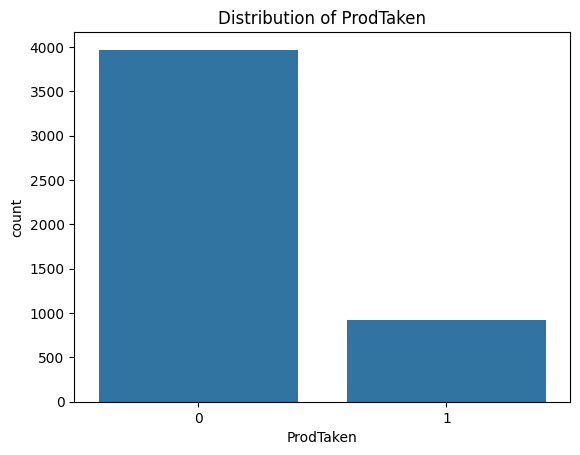

In [183]:
sns.countplot(x='ProdTaken', data=df)
plt.title('Distribution of ProdTaken')

Text(0.5, 1.0, 'Distribution of Age')

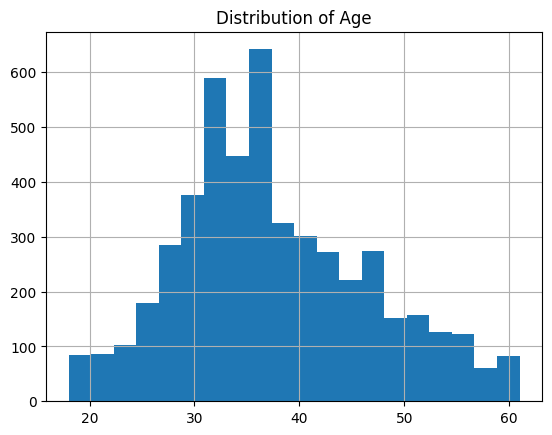

In [184]:
df.hist(column='Age', bins=20)
plt.title('Distribution of Age')

Text(0.5, 1.0, 'Distribution of Monthly Income')

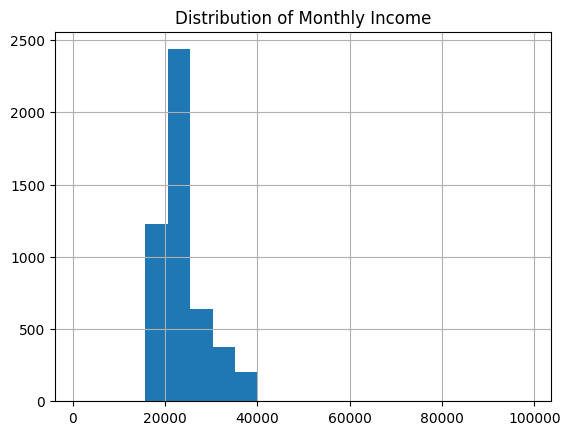

In [185]:
df.hist(column='MonthlyIncome', bins=20)
plt.title('Distribution of Monthly Income')

Text(0.5, 1.0, 'Distribution of Number of Trips')

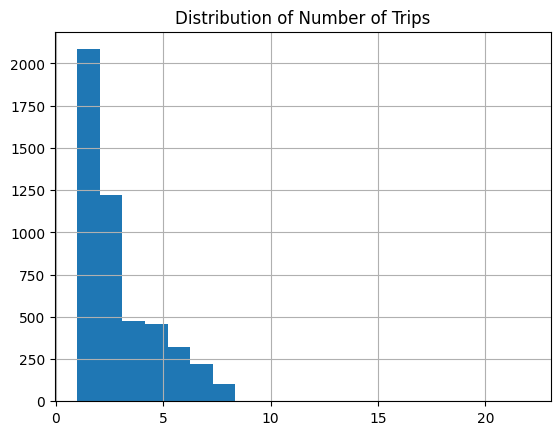

In [186]:
df.hist(column='NumberOfTrips', bins=20)
plt.title('Distribution of Number of Trips')

Text(0.5, 1.0, 'Distribution of Duration of Pitch')

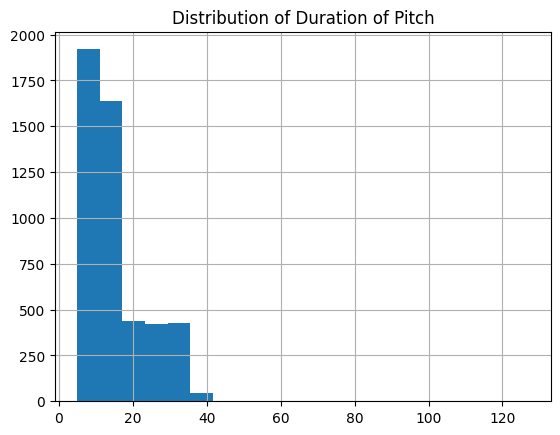

In [187]:
df.hist(column='DurationOfPitch', bins=20)
plt.title('Distribution of Duration of Pitch')

Text(0.5, 1.0, 'Distribution of Gender')

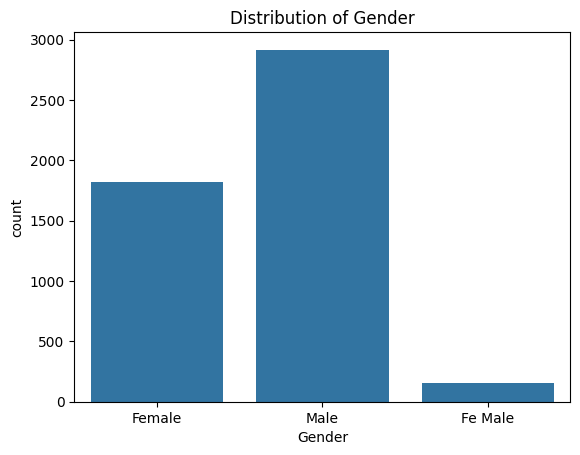

In [188]:
sns.countplot(x='Gender', data=df)
plt.title('Distribution of Gender')

Text(0.5, 1.0, 'Distribution of Marital Status')

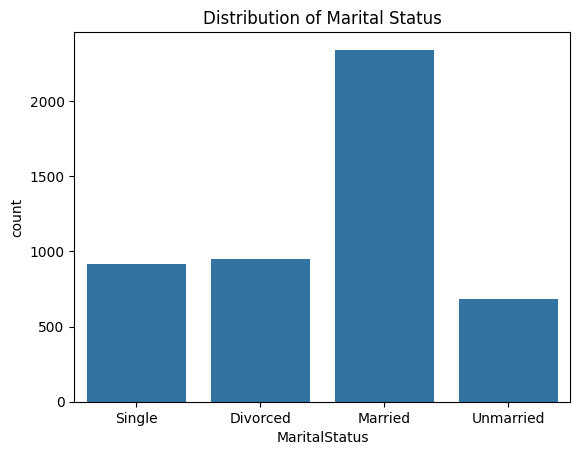

In [189]:
sns.countplot(x='MaritalStatus', data=df)
plt.title('Distribution of Marital Status')

Text(0.5, 1.0, 'Distribution of Occupation')

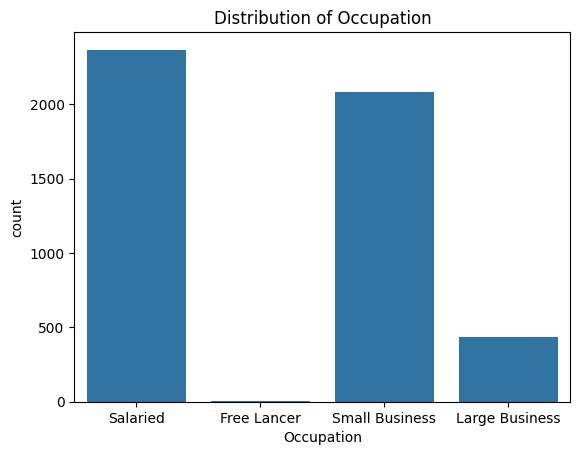

In [190]:
sns.countplot(x='Occupation', data=df)
plt.title('Distribution of Occupation')

Text(0.5, 1.0, 'Distribution of Type of Contact')

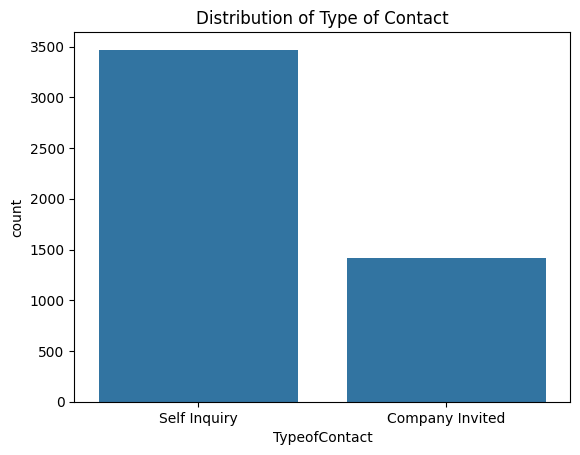

In [191]:
sns.countplot(x='TypeofContact', data=df)
plt.title('Distribution of Type of Contact')

Text(0.5, 1.0, 'Distribution of Product Pitched')

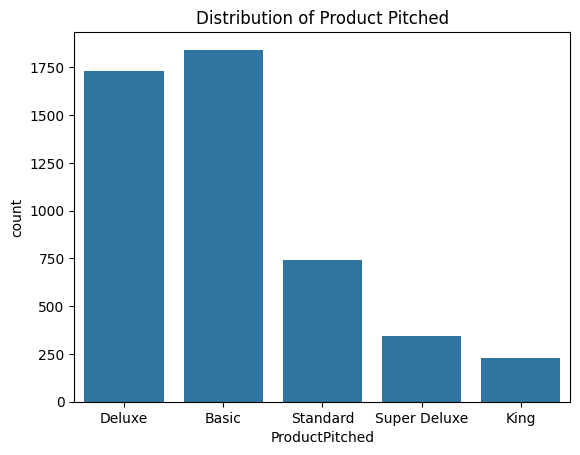

In [192]:
sns.countplot(x='ProductPitched', data=df)
plt.title('Distribution of Product Pitched')

Text(0.5, 1.0, 'Distribution of Designation')

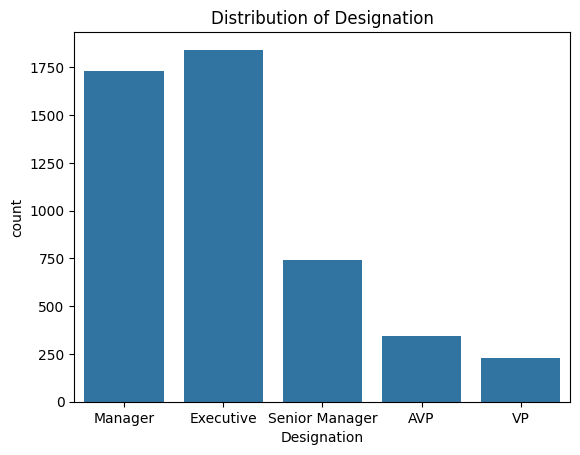

In [193]:
sns.countplot(x='Designation', data=df)
plt.title('Distribution of Designation')

<Axes: xlabel='Age'>

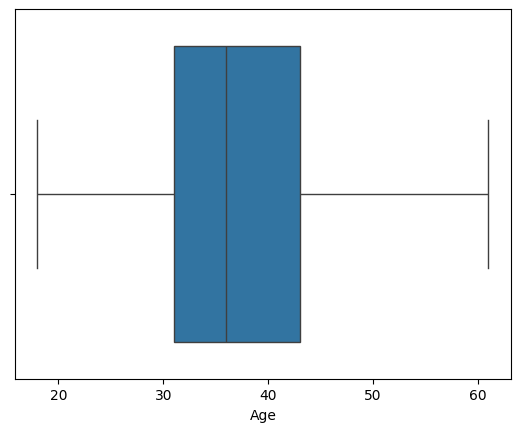

In [194]:
sns.boxplot(x=df['Age'])

<Axes: xlabel='MonthlyIncome'>

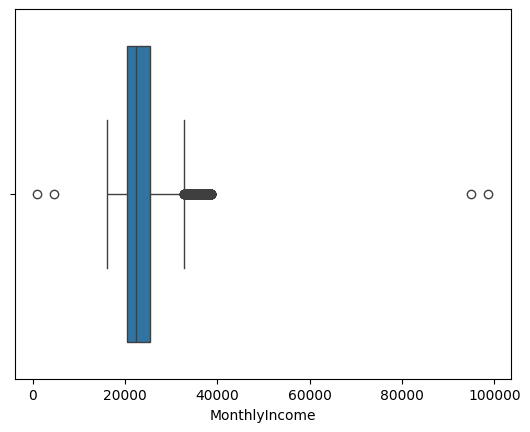

In [195]:
sns.boxplot(x=df['MonthlyIncome'])

<Axes: xlabel='DurationOfPitch'>

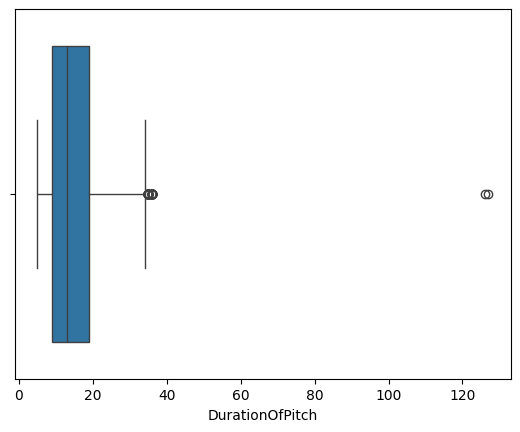

In [196]:
sns.boxplot(x=df['DurationOfPitch'])

<Axes: xlabel='NumberOfTrips'>

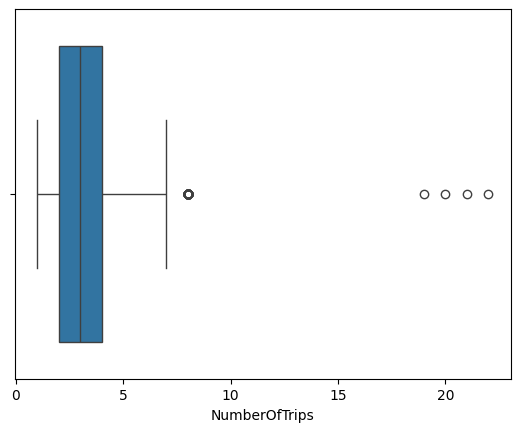

In [197]:
sns.boxplot(x=df['NumberOfTrips'])

### Bivariete

Text(0.5, 1.0, 'Age vs ProdTaken')

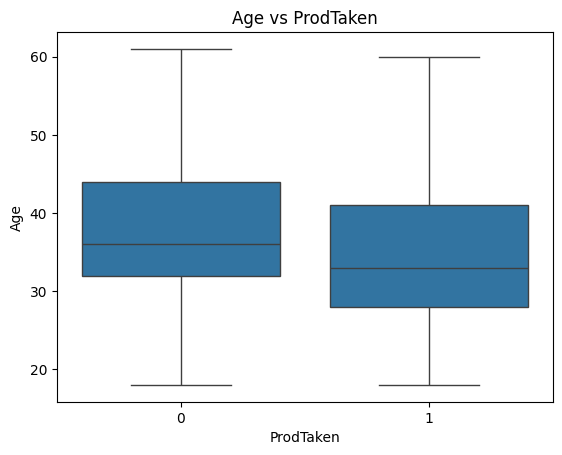

In [198]:
sns.boxplot(x='ProdTaken', y='Age', data=df)
plt.title('Age vs ProdTaken')

Text(0.5, 1.0, 'Monthly Income vs ProdTaken')

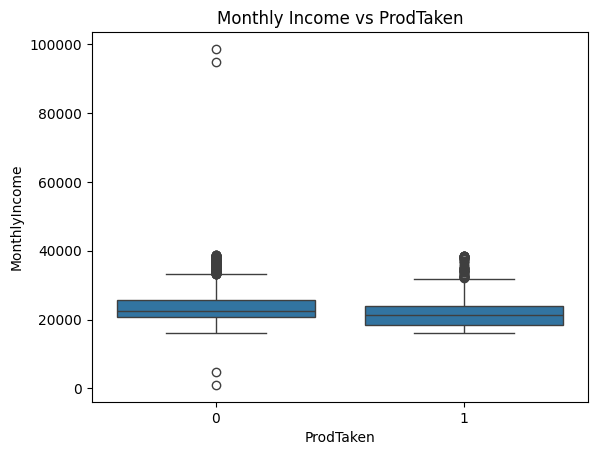

In [199]:
sns.boxplot(x='ProdTaken', y='MonthlyIncome', data=df)
plt.title('Monthly Income vs ProdTaken')

Text(0.5, 1.0, 'Gender vs ProdTaken')

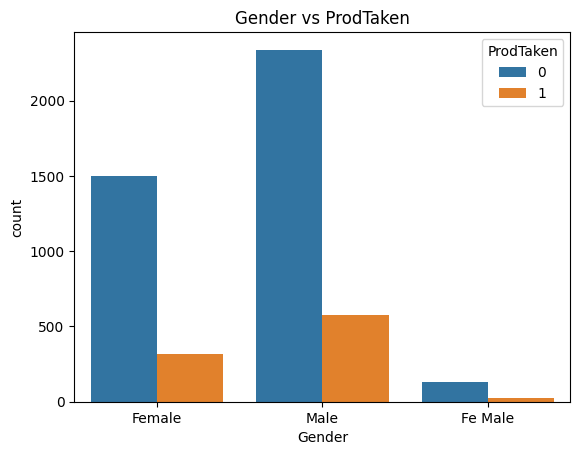

In [200]:
sns.countplot(x='Gender', hue='ProdTaken', data=df)
plt.title('Gender vs ProdTaken')

Text(0.5, 1.0, 'Product Pitched vs ProdTaken')

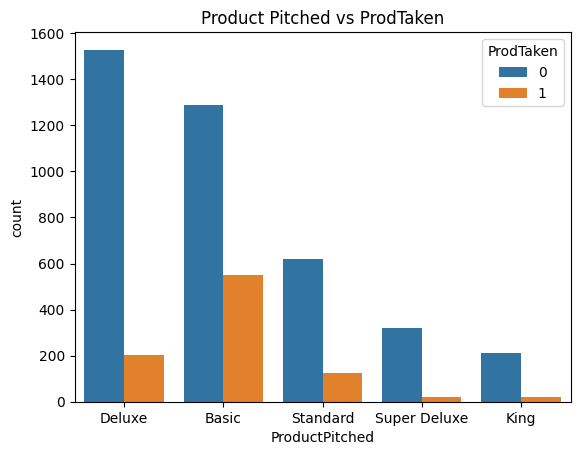

In [201]:
sns.countplot(x='ProductPitched', hue='ProdTaken', data=df)
plt.title('Product Pitched vs ProdTaken')

# ML Model Building 

In [202]:
from sklearn.model_selection import train_test_split
x = df.drop('ProdTaken', axis=1)
y = df['ProdTaken'] 


In [203]:
catefgorical_features = ['Gender', 'MaritalStatus', 'Occupation', 'TypeofContact', 'ProductPitched', 'Designation']
numerical_features = ['Age', 'MonthlyIncome', 'DurationOfPitch', 'NumberOfTrips', 'NumberOfFollowups', 'PreferredPropertyStar', 'NumberOfChildrenVisiting']

preprocessor = ColumnTransformer(
    transformers=[  
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(), catefgorical_features)
    ])


In [204]:
xtrain, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [205]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

In [206]:
knn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier())
])
knn_pipeline.fit(xtrain, y_train)
y_pred_knn = knn_pipeline.predict(x_test)

In [207]:
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])
lr_pipeline.fit(xtrain, y_train)
y_pred_lr = lr_pipeline.predict(x_test)

In [208]:
svm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(probability=True))
])
svm_pipeline.fit(xtrain, y_train)
y_pred_svm = svm_pipeline.predict(x_test)

In [209]:
dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier())
])
dt_pipeline.fit(xtrain, y_train)
y_pred_dt = dt_pipeline.predict(x_test)

In [210]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier())
])
rf_pipeline.fit(xtrain, y_train)
y_pred_rf = rf_pipeline.predict(x_test)

In [211]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score



def evaluate_model(y_test, y_pred, model_name):
    print(f"{model_name} Accuracy:", accuracy_score(y_test, y_pred))
    print(f"{model_name} Precision:", precision_score(y_test, y_pred))
    print(f"{model_name} Recall:", recall_score(y_test, y_pred))
    print(f"{model_name} F1 Score:", f1_score(y_test, y_pred))
    print("*"*40)

In [212]:
evaluate_model(y_test, y_pred_knn, "KNN")
evaluate_model(y_test, y_pred_lr, "Logistic Regression")
evaluate_model(y_test, y_pred_svm, "SVM")   
evaluate_model(y_test, y_pred_dt, "Decision Tree")
evaluate_model(y_test, y_pred_rf, "Random Forest")

KNN Accuracy: 0.8333333333333334
KNN Precision: 0.6235294117647059
KNN Recall: 0.28804347826086957
KNN F1 Score: 0.3940520446096654
****************************************
Logistic Regression Accuracy: 0.820040899795501
Logistic Regression Precision: 0.625
Logistic Regression Recall: 0.10869565217391304
Logistic Regression F1 Score: 0.18518518518518517
****************************************
SVM Accuracy: 0.8353783231083844
SVM Precision: 0.8285714285714286
SVM Recall: 0.15760869565217392
SVM F1 Score: 0.2648401826484018
****************************************
Decision Tree Accuracy: 0.8680981595092024
Decision Tree Precision: 0.6486486486486487
Decision Tree Recall: 0.6521739130434783
Decision Tree F1 Score: 0.6504065040650406
****************************************
Random Forest Accuracy: 0.8844580777096115
Random Forest Precision: 0.927710843373494
Random Forest Recall: 0.41847826086956524
Random Forest F1 Score: 0.5767790262172284
****************************************


| Model               | Accuracy  | Precision | Recall    | F1 Score  |
| ------------------- | --------- | --------- | --------- | --------- |
| KNN                 | 0.833     | 0.623     | 0.288     | 0.394     |
| Logistic Regression | 0.820     | 0.625     | 0.108     | 0.185     |
| SVM                 | 0.835     | 0.828     | 0.158     | 0.265     |
| Decision Tree       | 0.865     | 0.646     | **0.625** | **0.635** |
| Random Forest       | **0.883** | **0.898** | 0.429     | 0.581     |


#### If We look at only Accuracy

Evaluation Metric → Accuracy

So the best model is:

🥇 Random Forest

Reason:

Highest accuracy = 0.883

Highest precision = 0.897

Good F1 score

So academically:

Random Forest is the best performing model.

#### If We Consider Business Goal (Tourism Marketing)

Goal:

Identify customers who will buy travel packages.

So Recall is important.

Model	Recall
Decision Tree	0.625
Random Forest	0.429

Here:

🥇 Decision Tree detects more buyers

But:

Decision Trees overfit easily.

Random Forest is more stable and generalizable.

#### Balanced Evaluation (Best Overall Model)

We consider:

Accuracy

Precision

Recall

F1 Score

Model stability

Model	Conclusion
KNN	Weak recall
Logistic Regression	Very poor recall
SVM	Poor recall
Decision Tree	High recall but may overfit
Random Forest	Best overall performance

Therefore:

🏆 Random Forest is the best model.

### Why Random Forest Wins

Reasons you should write in your project:

1️⃣ Highest accuracy (88%)

2️⃣ Highest precision (89%)

3️⃣ Good F1 score

4️⃣ Handles non-linear relationships

5️⃣ Reduces overfitting compared to Decision Trees

6️⃣ Works well with mixed feature types

In [213]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Pipeline
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42))
])

# Hyperparameter grid
param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2],
    'classifier__max_features': ['sqrt', 'log2']
}

# GridSearchCV
grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Train model
grid_search.fit(xtrain, y_train)

# Best model
best_model = grid_search.best_estimator_

# Predictions
y_pred_rf = best_model.predict(x_test)

# Evaluation
print("Best Parameters:", grid_search.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

Best Parameters: {'classifier__max_depth': 20, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 300}
Accuracy: 0.8875255623721882
Precision: 0.8557692307692307
Recall: 0.483695652173913
F1 Score: 0.6180555555555556


In [214]:
import joblib

best_model = grid_search.best_estimator_

joblib.dump(best_model, "Travel_package.pkl")

['Travel_package.pkl']

In [216]:
import numpy as np

preds = best_model.predict(x_test)
np.unique(preds, return_counts=True)

(array([0, 1]), array([874, 104]))